In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix.csv")

# View data
df.head()

# Basic info
df.info()

# Check null values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [3]:
# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year & month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

C:\Users\HP\AppData\Local\Temp\ipykernel_7156\2924521325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_7156\2924521325.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y", at position 1442. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

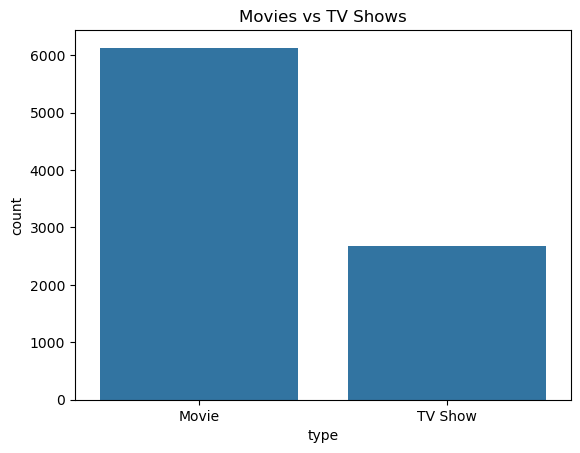

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [4]:
type_count = df['type'].value_counts()

plt.figure()
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

print(type_count)


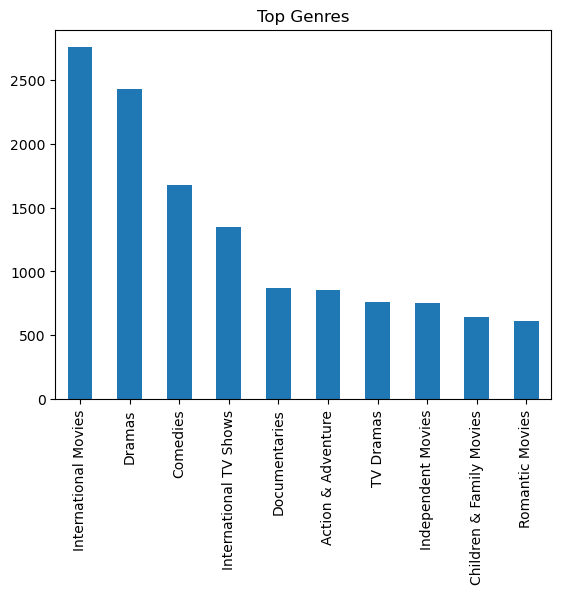

In [5]:
genre = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genre.value_counts().head(10)

top_genres.plot(kind='bar')
plt.title("Top Genres")
plt.show()

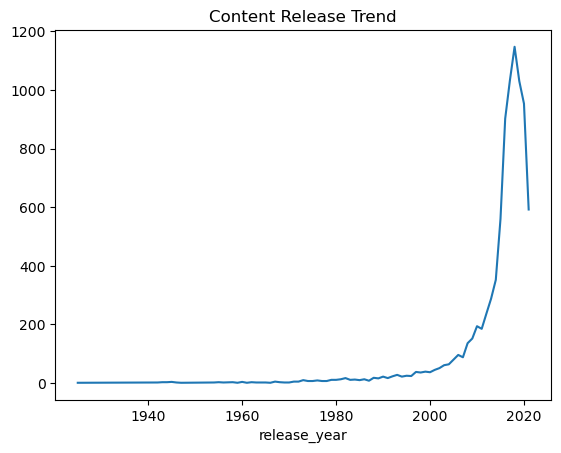

In [6]:
year_count = df['release_year'].value_counts().sort_index()

plt.figure()
year_count.plot()
plt.title("Content Release Trend")
plt.show()

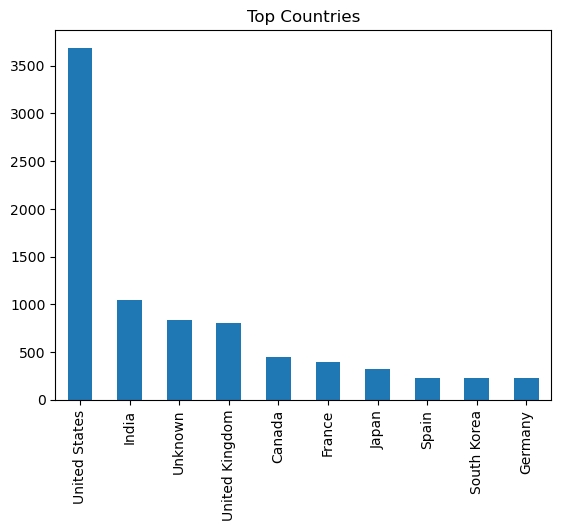

In [7]:
country = df['country'].str.split(', ', expand=True).stack()
top_country = country.value_counts().head(10)

top_country.plot(kind='bar')
plt.title("Top Countries")
plt.show()

In [8]:
added_year = df['year_added'].value_counts().sort_index()

added_year.plot()
plt.title("Content Added Over Years")
plt.show()

KeyError: 'year_added'

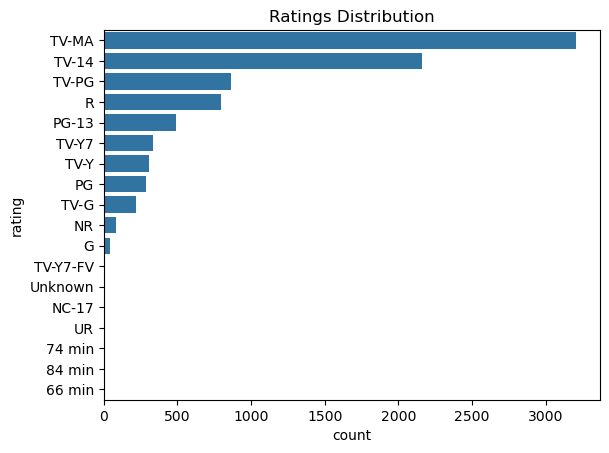

In [9]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Ratings Distribution")
plt.show()

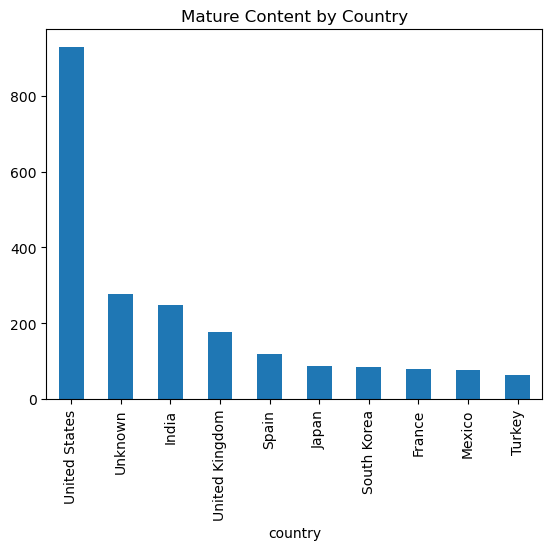

In [10]:
mature = df[df['rating'] == 'TV-MA']
mature_country = mature['country'].value_counts().head(10)

mature_country.plot(kind='bar')
plt.title("Mature Content by Country")
plt.show()

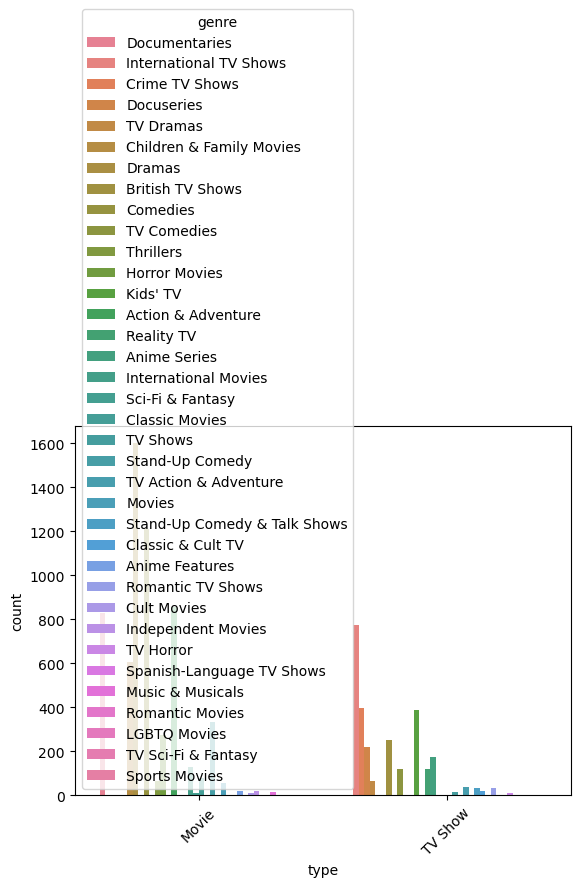

In [11]:
df['genre'] = df['listed_in'].str.split(',').str[0]

sns.countplot(x='type', hue='genre', data=df)
plt.xticks(rotation=45)
plt.show()

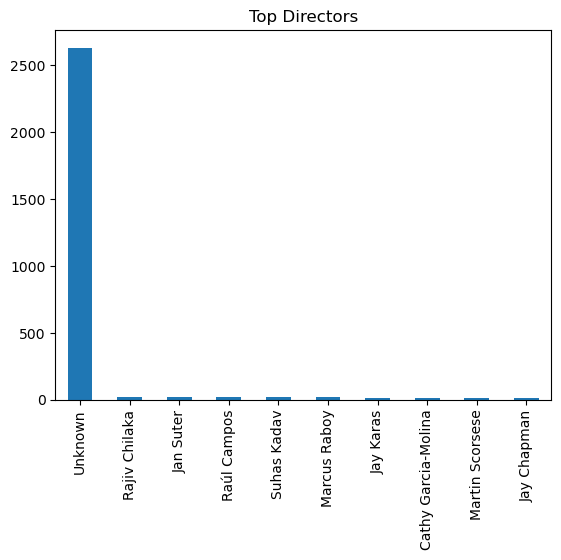

In [12]:
director = df['director'].str.split(', ', expand=True).stack()
top_director = director.value_counts().head(10)

top_director.plot(kind='bar')
plt.title("Top Directors")
plt.show()

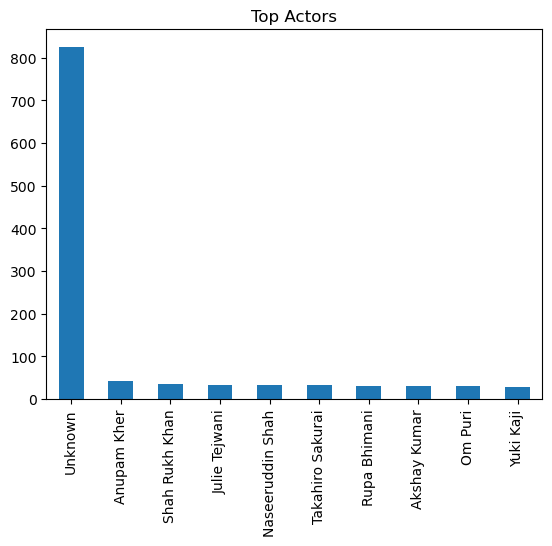

In [13]:
actors = df['cast'].str.split(', ', expand=True).stack()
top_actors = actors.value_counts().head(10)

top_actors.plot(kind='bar')
plt.title("Top Actors")
plt.show()

In [14]:
movies = df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

print("Average Movie Duration:", movies['duration'].mean())

Average Movie Duration: 99.57718668407311


C:\Users\HP\AppData\Local\Temp\ipykernel_7156\332061585.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)


C:\Users\HP\AppData\Local\Temp\ipykernel_7156\1837513826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv['duration'] = tv['duration'].str.replace(' Seasons', '').str.replace(' Season', '')
C:\Users\HP\AppData\Local\Temp\ipykernel_7156\1837513826.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv['duration'] = tv['duration'].astype(float)


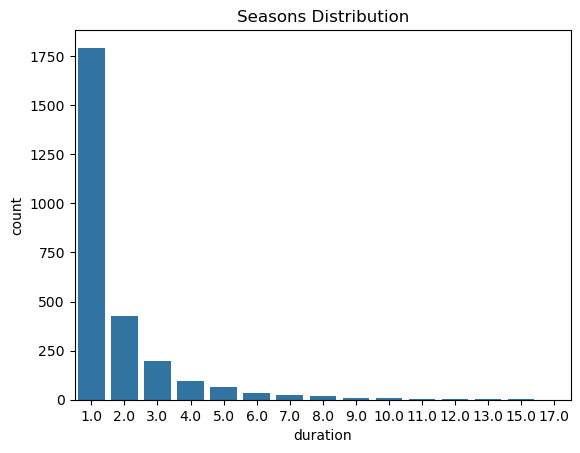

In [15]:
tv = df[df['type'] == 'TV Show']

tv['duration'] = tv['duration'].str.replace(' Seasons', '').str.replace(' Season', '')
tv['duration'] = tv['duration'].astype(float)

sns.countplot(x='duration', data=tv)
plt.title("Seasons Distribution")
plt.show()

In [16]:
sns.countplot(x='month_added', data=df)
plt.title("Content Added by Month")
plt.show()

ValueError: Could not interpret value `month_added` for `x`. An entry with this name does not appear in `data`.

In [17]:
trend = df.groupby(['year_added', 'type']).size().unstack()

trend.plot()
plt.title("Movies vs TV Shows Trend")
plt.show()


KeyError: 'year_added'